In [1]:
# STEP 1: Install required library
!pip install imbalanced-learn -q

In [2]:
# STEP 2: Import libraries
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skimage.feature import local_binary_pattern

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from imblearn.over_sampling import SMOTE

In [3]:
# STEP 3: Extract Dataset.zip cleanly

zip_path = "/content/rice_leaf_diseases.zip"
extract_path = "/content/extracted_dataset"

if os.path.exists(extract_path):
    import shutil
    shutil.rmtree(extract_path)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [4]:
import os
import shutil

source_dataset_path = "/content/extracted_dataset/rice_leaf_diseases"
combined_dataset_path = "/content/Rice_Dataset"

# remove old folder
if os.path.exists(combined_dataset_path):
    shutil.rmtree(combined_dataset_path)

# create main folder
os.makedirs(combined_dataset_path, exist_ok=True)

# get all class names automatically
class_names = os.listdir(source_dataset_path)

# create folders automatically
for class_name in class_names:

    os.makedirs(
        os.path.join(combined_dataset_path, class_name),
        exist_ok=True
    )

# copy images class-wise
for class_name in class_names:

    source_folder = os.path.join(source_dataset_path, class_name)

    destination_folder = os.path.join(
        combined_dataset_path,
        class_name
    )

    for file_name in os.listdir(source_folder):

        source_file = os.path.join(source_folder, file_name)

        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            shutil.copy2(
                source_file,
                destination_folder
            )

print("Dataset organized successfully!")

# print image counts
for class_name in class_names:

    folder_path = os.path.join(
        combined_dataset_path,
        class_name
    )

    print(
        class_name,
        "images:",
        len(os.listdir(folder_path))
    )

Dataset organized successfully!
Bacterial leaf blight images: 40
Brown spot images: 40
Leaf smut images: 40


In [5]:
# STEP: Set dataset directory

dataset_path = "/content/Rice_Dataset"

# get all class folders automatically
class_names = os.listdir(dataset_path)

# print image counts
for class_name in class_names:

    class_path = os.path.join(dataset_path, class_name)

    print(
        class_name,
        "images:",
        len(os.listdir(class_path))
    )

Bacterial leaf blight images: 40
Brown spot images: 40
Leaf smut images: 40


In [6]:
image_paths = []
labels = []

# get all class names automatically
class_names = os.listdir(dataset_path)

# create class mapping automatically
class_map = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

print("Class Mapping:")
print(class_map)

# load image paths and labels
for class_name, label in class_map.items():

    folder_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(folder_path):

        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            full_path = os.path.join(
                folder_path,
                file_name
            )

            image_paths.append(full_path)

            labels.append(label)

print("Total images found:", len(image_paths))
print("Total labels:", len(labels))
print("First image path:", image_paths[0])

Class Mapping:
{'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}
Total images found: 120
Total labels: 120
First image path: /content/Rice_Dataset/Bacterial leaf blight/DSC_0381.JPG


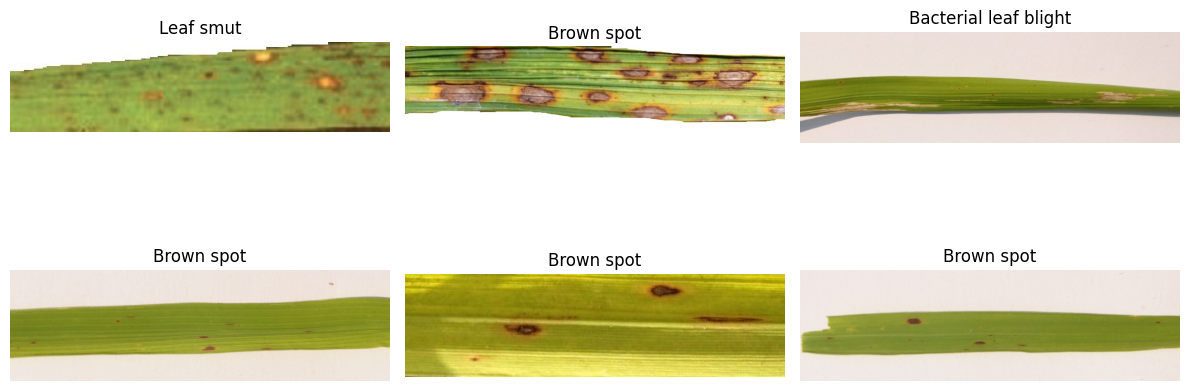

In [7]:
import cv2
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12, 6))

for i in range(6):

    idx = random.randint(0, len(image_paths) - 1)

    img_path = image_paths[idx]

    img = cv2.imread(img_path)

    if img is None:
        print("Could not read:", img_path)
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # get class name from label
    class_name = list(class_map.keys())[
        list(class_map.values()).index(labels[idx])
    ]

    plt.subplot(2, 3, i + 1)

    plt.imshow(img_rgb)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [8]:
def show_sample_images(dataset_path, samples=4):

    # get all class names automatically
    classes = os.listdir(dataset_path)

    plt.figure(figsize=(4 * samples, 4 * len(classes)))

    plot_index = 1

    for class_name in classes:

        folder_path = os.path.join(dataset_path, class_name)

        image_files = os.listdir(folder_path)[:samples]

        for file_name in image_files:

            img_path = os.path.join(
                folder_path,
                file_name
            )

            img = cv2.imread(img_path)

            if img is None:
                continue

            img_rgb = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )

            plt.subplot(
                len(classes),
                samples,
                plot_index
            )

            plt.imshow(img_rgb)

            plt.title(class_name)

            plt.axis("off")

            plot_index += 1

    plt.tight_layout()

    plt.show()

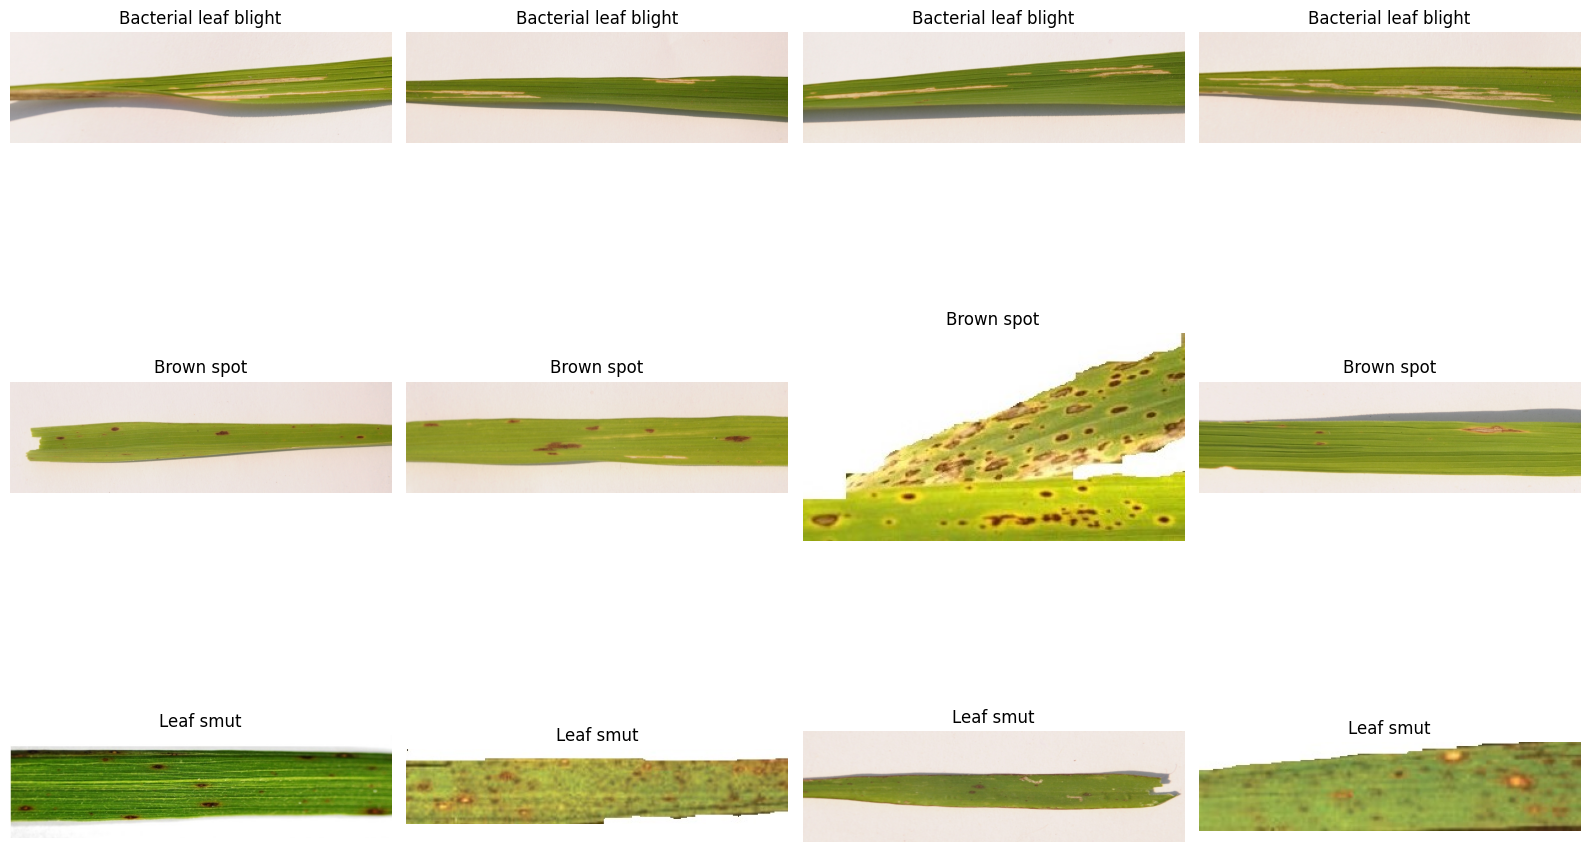

In [9]:
show_sample_images("/content/Rice_Dataset", samples=4)

In [10]:
def preprocess_image(img):

    # 1. Resize image
    resized = cv2.resize(img, (128, 128))

    # 2. Noise removal
    denoised = cv2.medianBlur(resized, 5)

    # 3. Convert to grayscale
    gray = cv2.cvtColor(
        denoised,
        cv2.COLOR_BGR2GRAY
    )

    # 4. Histogram Equalization
    equalized = cv2.equalizeHist(gray)

    # 5. Convert to HSV
    hsv = cv2.cvtColor(
        denoised,
        cv2.COLOR_BGR2HSV
    )

    # 6. Edge Detection
    edges = cv2.Canny(
        equalized,
        100,
        200
    )

    return (
        resized,
        denoised,
        gray,
        equalized,
        hsv,
        edges
    )

In [11]:
def show_preprocessing_steps(img_path):

    img = cv2.imread(img_path)

    if img is None:
        print("Image could not be loaded")
        return

    # Original image for display
    original_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # Apply preprocessing
    resized, denoised, gray, equalized, hsv, edges = preprocess_image(img)

    # Convert BGR images to RGB for matplotlib
    resized_rgb = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2RGB
    )

    denoised_rgb = cv2.cvtColor(
        denoised,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(18, 8))

    # Original Image
    plt.subplot(2, 3, 1)

    plt.imshow(original_rgb)

    plt.title("Original Image")

    plt.axis("off")

    # Resized Image
    plt.subplot(2, 3, 2)

    plt.imshow(resized_rgb)

    plt.title("Resized")

    plt.axis("off")

    # Denoised Image
    plt.subplot(2, 3, 3)

    plt.imshow(denoised_rgb)

    plt.title("Denoised")

    plt.axis("off")

    # Grayscale Image
    plt.subplot(2, 3, 4)

    plt.imshow(gray, cmap="gray")

    plt.title("Grayscale")

    plt.axis("off")

    # Histogram Equalization
    plt.subplot(2, 3, 5)

    plt.imshow(equalized, cmap="gray")

    plt.title("Histogram Equalized")

    plt.axis("off")

    # Edge Detection
    plt.subplot(2, 3, 6)

    plt.imshow(edges, cmap="gray")

    plt.title("Edge Detection")

    plt.axis("off")

    plt.tight_layout()

    plt.show()

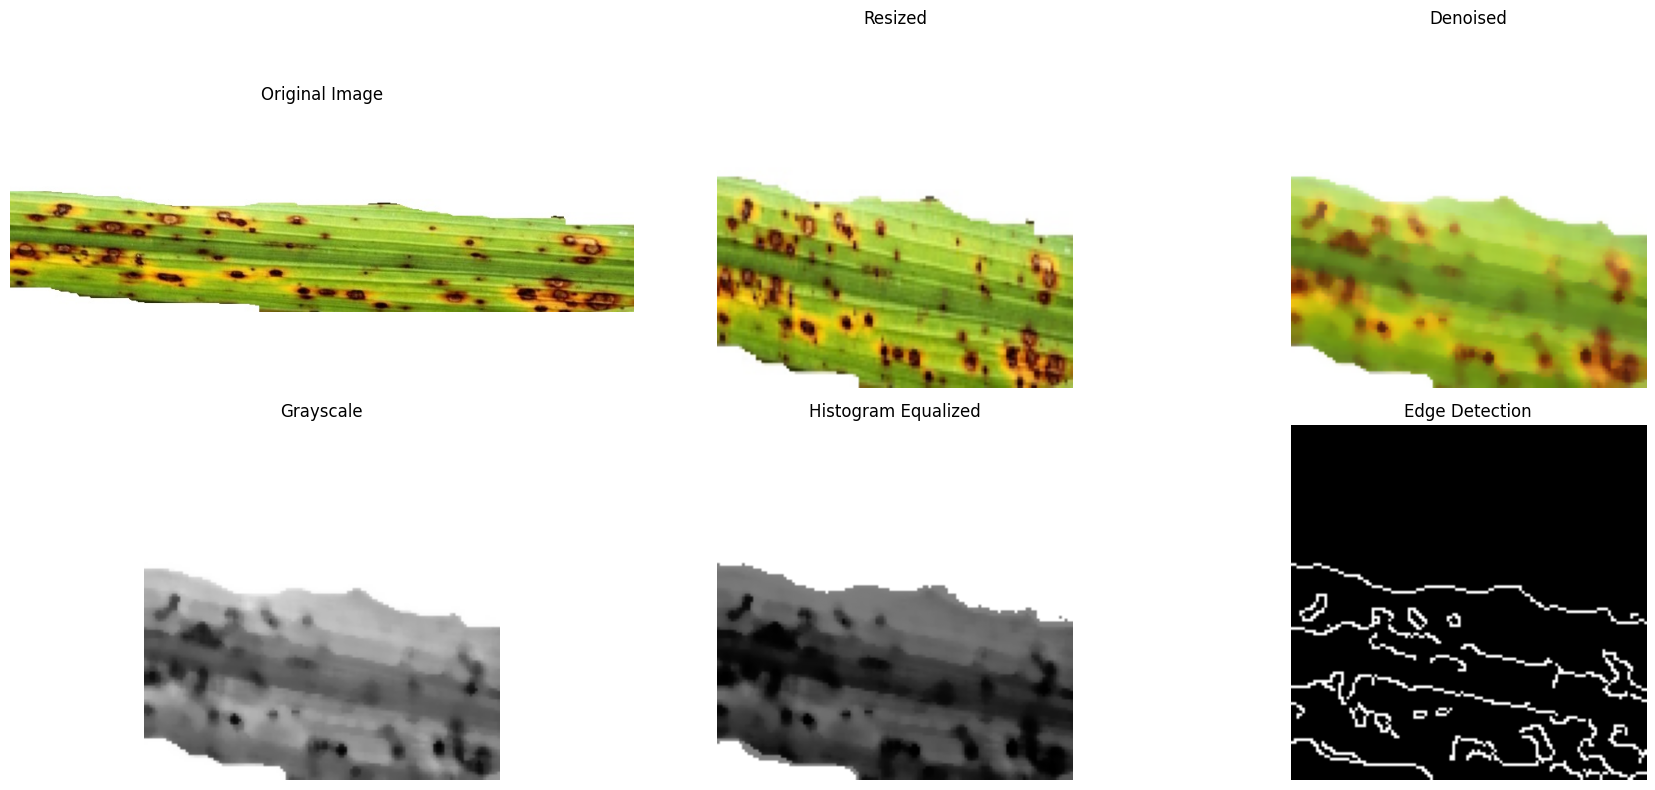

In [12]:
show_preprocessing_steps(
    "/content/Rice_Dataset/Brown spot/DSC_0100.jpg"
)

In [13]:
def show_contours(img_path):

    img = cv2.imread(img_path)

    if img is None:
        print("Image not found")
        return

    # resize image
    resized = cv2.resize(
        img,
        (128, 128)
    )

    # convert to grayscale
    gray = cv2.cvtColor(
        resized,
        cv2.COLOR_BGR2GRAY
    )

    # edge detection
    edges = cv2.Canny(
        gray,
        100,
        200
    )

    # find contours
    contours, hierarchy = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # copy image for contour drawing
    contour_image = resized.copy()

    # draw contours
    cv2.drawContours(
        contour_image,
        contours,
        -1,
        (0, 255, 0),
        2
    )

    # convert BGR to RGB
    contour_rgb = cv2.cvtColor(
        contour_image,
        cv2.COLOR_BGR2RGB
    )

    # show output
    plt.figure(figsize=(6, 6))

    plt.imshow(contour_rgb)

    plt.title(
        f"Contours Found: {len(contours)}"
    )

    plt.axis("off")

    plt.show()

In [14]:
import os

print(os.listdir("/content/Rice_Dataset/Brown spot")[:5])

['DSC_0337.JPG', 'DSC_0303.JPG', 'DSC_0119.jpg', 'DSC_0295.JPG', 'DSC_0121.jpg']


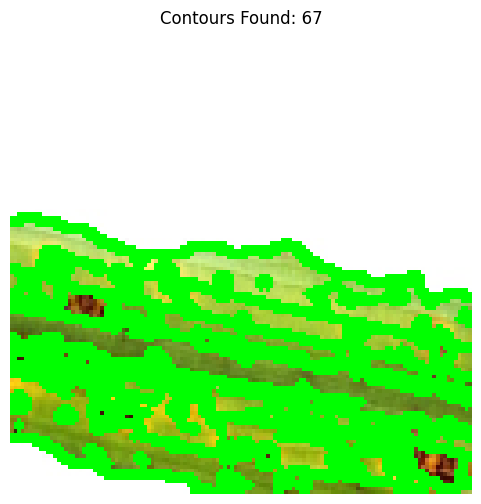

In [16]:
show_contours(
    "/content/Rice_Dataset/Brown spot/DSC_0100.jpg"
)

In [17]:
from skimage.feature import local_binary_pattern

def extract_features(img):

    features = []

    # =========================
    # PREPROCESSING
    # =========================

    resized = cv2.resize(
        img,
        (128, 128)
    )

    denoised = cv2.medianBlur(
        resized,
        5
    )

    gray = cv2.cvtColor(
        denoised,
        cv2.COLOR_BGR2GRAY
    )

    equalized = cv2.equalizeHist(gray)

    hsv = cv2.cvtColor(
        denoised,
        cv2.COLOR_BGR2HSV
    )

    edges = cv2.Canny(
        equalized,
        100,
        200
    )

    # =========================
    # 1. COLOR FEATURES
    # HSV Histogram
    # =========================

    h_hist = cv2.calcHist(
        [hsv],
        [0],
        None,
        [32],
        [0, 180]
    )

    h_hist = h_hist.flatten()

    h_hist = h_hist / (
        h_hist.sum() + 1e-6
    )

    features.extend(h_hist)

    # =========================
    # 2. TEXTURE FEATURES
    # LBP
    # =========================

    lbp = local_binary_pattern(
        equalized,
        P=8,
        R=1,
        method="uniform"
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=10,
        range=(0, 10)
    )

    lbp_hist = lbp_hist.astype(
        "float32"
    )

    lbp_hist = lbp_hist / (
        lbp_hist.sum() + 1e-6
    )

    features.extend(lbp_hist)

    # =========================
    # 3. SHAPE FEATURES
    # =========================

    contours, hierarchy = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    area = sum(
        cv2.contourArea(c)
        for c in contours
    )

    perimeter = sum(
        cv2.arcLength(c, True)
        for c in contours
    )

    circularity = (
        4 * np.pi * area
    ) / (
        (perimeter ** 2) + 1e-6
    )

    features.extend([
        area,
        perimeter,
        circularity
    ])

    return np.array(
        features,
        dtype=np.float32
    )

In [18]:
sample_img = cv2.imread(
    "/content/Rice_Dataset/Brown spot/DSC_0100.jpg"
)

features = extract_features(sample_img)

print("Feature Vector Shape:", features.shape)

print("\nFirst 20 Features:\n")

print(features[:20])

Feature Vector Shape: (45,)

First 20 Features:

[4.8657227e-01 6.8359375e-03 1.7883301e-02 3.4606934e-02 5.2062988e-02
 8.3007812e-02 2.3962402e-01 7.1228027e-02 2.9907227e-03 0.0000000e+00
 2.9907227e-03 0.0000000e+00 6.1035156e-05 0.0000000e+00 0.0000000e+00
 0.0000000e+00 1.7089844e-03 0.0000000e+00 0.0000000e+00 0.0000000e+00]


In [19]:
X = []
y = []

for img_path, label in zip(image_paths, labels):

    img = cv2.imread(img_path)

    # corrupted image handling
    if img is None:

        print(
            "Skipping corrupted image:",
            img_path
        )

        continue

    try:

        # extract features
        feature_vector = extract_features(img)

        # remove invalid values
        if np.isfinite(feature_vector).all():

            X.append(feature_vector)

            y.append(label)

    except Exception as e:

        print(
            "Error processing:",
            img_path
        )

        print(e)

# convert into numpy arrays
X = np.array(
    X,
    dtype=np.float32
)

y = np.array(y)

print(
    "Feature Matrix Shape:",
    X.shape
)

print(
    "Label Vector Shape:",
    y.shape
)

Feature Matrix Shape: (120, 45)
Label Vector Shape: (120,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    "Training Data Shape:",
    X_train.shape
)

print(
    "Testing Data Shape:",
    X_test.shape
)

print("\nTraining Labels:")

print(np.bincount(y_train))

print("\nTesting Labels:")

print(np.bincount(y_test))

Training Data Shape: (96, 45)
Testing Data Shape: (24, 45)

Training Labels:
[32 32 32]

Testing Labels:
[8 8 8]


In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")

print(np.bincount(y_train))

print("\nAfter SMOTE:")

print(np.bincount(y_train_smote))

print("\nBalanced Training Shape:")

print(X_train_smote.shape)

Before SMOTE:
[32 32 32]

After SMOTE:
[32 32 32]

Balanced Training Shape:
(96, 45)


In [22]:
models = {

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Naive Bayes": GaussianNB()
}

results = []

for model_name, model in models.items():

    pipeline = Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "classifier",
            model
        )
    ])

    # train model
    pipeline.fit(
        X_train_smote,
        y_train_smote
    )

    # prediction
    y_pred = pipeline.predict(X_test)

    # accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    results.append([
        model_name,
        accuracy
    ])

    print(
        f"{model_name} Accuracy: {accuracy:.4f}"
    )

KNN Accuracy: 0.5833
SVM Accuracy: 0.6667
Random Forest Accuracy: 0.7083
Logistic Regression Accuracy: 0.6250
Decision Tree Accuracy: 0.5417
Extra Trees Accuracy: 0.7500
Gradient Boosting Accuracy: 0.7917
Naive Bayes Accuracy: 0.3333


In [23]:
best_model = ExtraTreesClassifier(
    random_state=42
)

best_pipeline = Pipeline([

    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        best_model
    )
])

# train model
best_pipeline.fit(
    X_train_smote,
    y_train_smote
)

# prediction
y_pred = best_pipeline.predict(
    X_test
)

In [24]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print(
    "Accuracy :",
    accuracy_score(y_test, y_pred)
)

# weighted average for multiclass
print(
    "\nPrecision :",
    precision_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print(
    "Recall :",
    recall_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print("\nClassification Report:\n")

print(

    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

Accuracy : 0.75

Precision : 0.7756132756132756
Recall : 0.75
F1 Score : 0.750375939849624

Classification Report:

                       precision    recall  f1-score   support

Bacterial leaf blight       0.64      0.88      0.74         8
           Brown spot       0.83      0.62      0.71         8
            Leaf smut       0.86      0.75      0.80         8

             accuracy                           0.75        24
            macro avg       0.78      0.75      0.75        24
         weighted avg       0.78      0.75      0.75        24



[[7 0 1]
 [3 5 0]
 [1 1 6]]


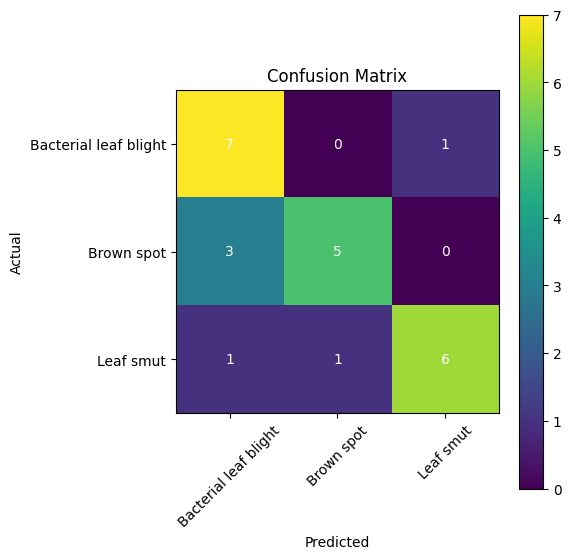

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

plt.figure(figsize=(6, 6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

# dynamic class labels
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

# add values inside matrix
for i in range(len(class_names)):

    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white"
        )

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

# convert multiclass labels into binary format
y_test_bin = label_binarize(
    y_test,
    classes=range(len(class_names))
)

# probability scores
y_prob = best_pipeline.predict_proba(X_test)

# ROC + AUC for each class
for i, class_name in enumerate(class_names):

    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    auc_score = roc_auc_score(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    print(
        f"{class_name} AUC Score : {auc_score:.4f}"
    )

Bacterial leaf blight AUC Score : 0.8594
Brown spot AUC Score : 0.8359
Leaf smut AUC Score : 0.9844


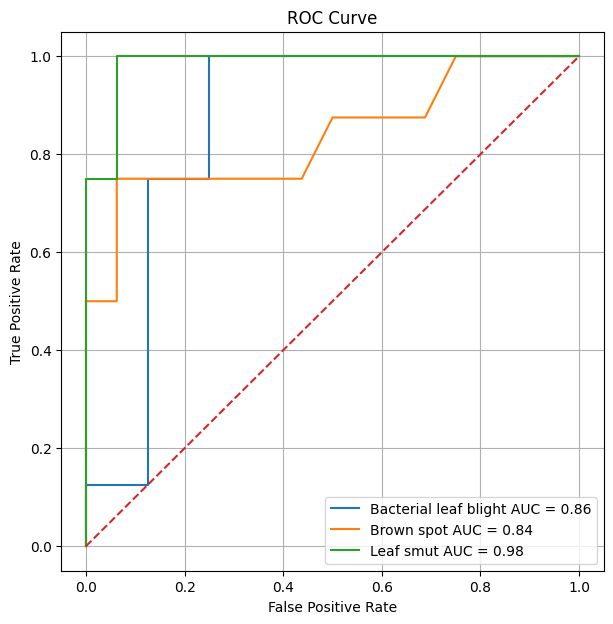

In [27]:
plt.figure(figsize=(7, 7))

# ROC curve for each class
for i, class_name in enumerate(class_names):

    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    auc_score = roc_auc_score(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {auc_score:.2f}"
    )

# random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [28]:
train_sizes, train_scores, validation_scores = learning_curve(

    estimator=best_pipeline,

    X=X_train_smote,

    y=y_train_smote,

    train_sizes=np.linspace(
        0.1,
        1.0,
        6
    ),

    cv=5,

    scoring="accuracy"
)

In [29]:
train_mean = np.mean(
    train_scores,
    axis=1
)

validation_mean = np.mean(
    validation_scores,
    axis=1
)

print("Training Accuracy:\n")

print(train_mean)

print("\nValidation Accuracy:\n")

print(validation_mean)

Training Accuracy:

[1. 1. 1. 1. 1. 1.]

Validation Accuracy:

[0.37473684 0.43789474 0.55315789 0.52263158 0.67789474 0.67842105]


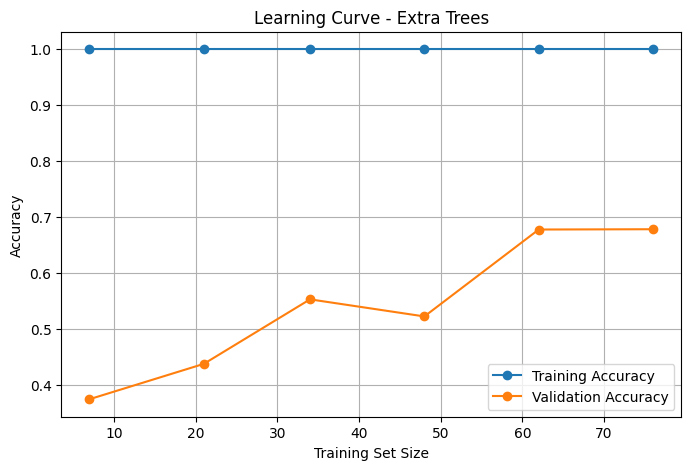

In [30]:
plt.figure(figsize=(8, 5))

# training accuracy
plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label="Training Accuracy"
)

# validation accuracy
plt.plot(
    train_sizes,
    validation_mean,
    marker='o',
    label="Validation Accuracy"
)

plt.xlabel("Training Set Size")

plt.ylabel("Accuracy")

plt.title("Learning Curve - Extra Trees")

plt.legend()

plt.grid(True)

plt.show()

Total Features: 45

Top 10 Important Features:

        Feature  Importance
36        LBP_4    0.059698
0    HSV_Hist_0    0.052403
37        LBP_5    0.049756
1    HSV_Hist_1    0.047202
44  Circularity    0.045707
39        LBP_7    0.041975
3    HSV_Hist_3    0.041848
4    HSV_Hist_4    0.040967
5    HSV_Hist_5    0.040650
42         Area    0.037833


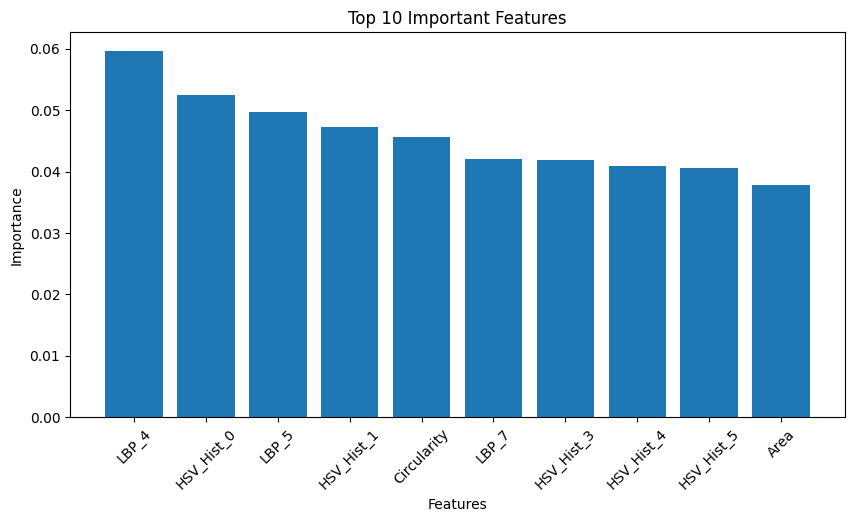

In [31]:
# =========================
# FEATURE IMPORTANCE
# =========================

feature_importance = best_pipeline.named_steps[
    "classifier"
].feature_importances_

print(
    "Total Features:",
    len(feature_importance)
)

# =========================
# FEATURE NAMES
# =========================

feature_names = []

# HSV Histogram Features
for i in range(32):

    feature_names.append(
        f"HSV_Hist_{i}"
    )

# LBP Texture Features
for i in range(10):

    feature_names.append(
        f"LBP_{i}"
    )

# Shape Features
feature_names.extend([

    "Area",

    "Perimeter",

    "Circularity"
])

# =========================
# CREATE DATAFRAME
# =========================

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": feature_importance
})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

# =========================
# PRINT TOP FEATURES
# =========================

print(
    "\nTop 10 Important Features:\n"
)

print(
    importance_df.head(10)
)

# =========================
# VISUALIZATION
# =========================

top_features = importance_df.head(10)

plt.figure(figsize=(10, 5))

plt.bar(

    top_features["Feature"],

    top_features["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Top 10 Important Features")

plt.show()

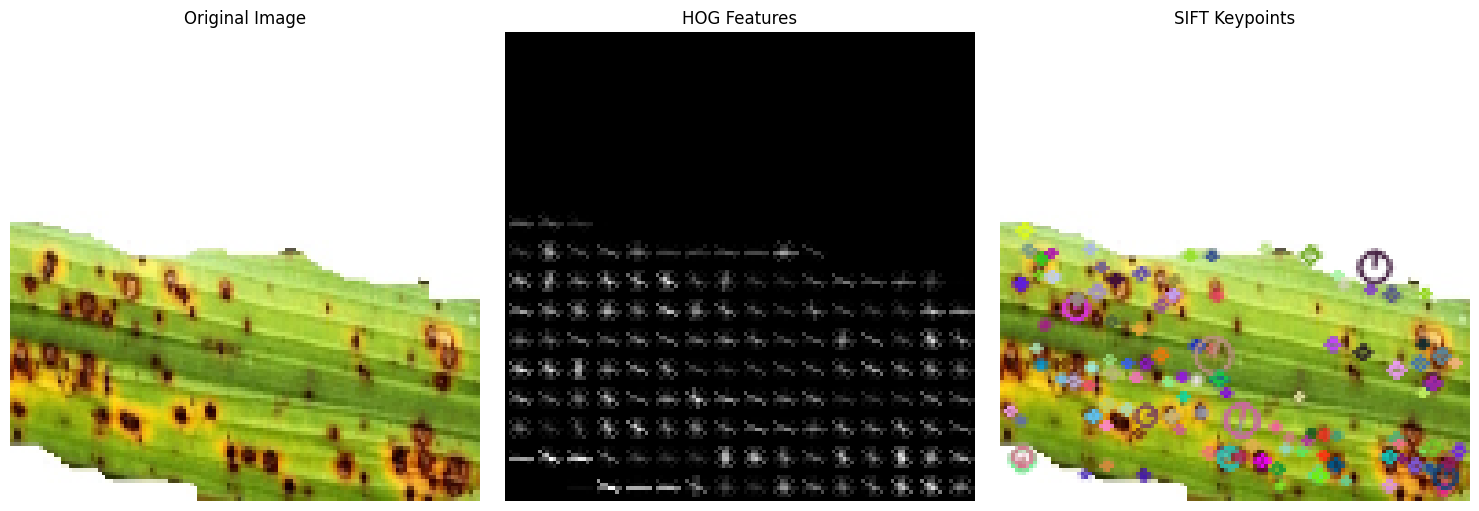

HOG Feature Vector Length: 8100
Number of SIFT Keypoints: 134


In [32]:
# =========================
# HOG + SIFT VISUALIZATION
# =========================

from skimage.feature import hog

img_path = "/content/Rice_Dataset/Brown spot/DSC_0100.jpg"

img = cv2.imread(img_path)

# resize
img = cv2.resize(
    img,
    (128, 128)
)

# grayscale
gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

# =========================
# HOG FEATURE VISUALIZATION
# =========================

hog_features, hog_image = hog(

    gray,

    orientations=9,

    pixels_per_cell=(8, 8),

    cells_per_block=(2, 2),

    visualize=True
)

# =========================
# SIFT FEATURE VISUALIZATION
# =========================

sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(
    gray,
    None
)

sift_image = cv2.drawKeypoints(

    img,

    keypoints,

    None,

    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# =========================
# DISPLAY RESULTS
# =========================

plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)

plt.imshow(
    cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Original Image")

plt.axis("off")

# HOG Visualization
plt.subplot(1, 3, 2)

plt.imshow(
    hog_image,
    cmap="gray"
)

plt.title("HOG Features")

plt.axis("off")

# SIFT Visualization
plt.subplot(1, 3, 3)

plt.imshow(
    cv2.cvtColor(
        sift_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("SIFT Keypoints")

plt.axis("off")

plt.tight_layout()

plt.show()

# =========================
# PRINT FEATURE DETAILS
# =========================

print(
    "HOG Feature Vector Length:",
    len(hog_features)
)

print(
    "Number of SIFT Keypoints:",
    len(keypoints)
)